In [8]:
import subprocess, sys

for pkg in ['pandas', 'numpy', 'matplotlib', 'seaborn', 'plotly', 'openpyxl']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All libraries are ready!')


All libraries are ready!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('libraries import successfully!')

libraries import successfully!


In [2]:
# No long path needed if the file is in the same folder!
df = pd.read_excel("sales_records_dataset.xlsx")

print(f"Dataset loaded! Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded! Shape: 1000 rows, 14 columns


In [21]:
df.head()

,Order_ID,Customer_Name,Gender,Region,Product_Category,Product_Name,Quantity,Unit_Price,Total_Sales,Discount,Profit,Order_Date,Payment_Method,Sales_Rep
0,ORD1001,Zainab James,Female,West,Electronics,Laptop,3.0,21785.0,65355.0,4346.0,11889.607718,2022-07-18,Cash,Rep_D
1,NaN,Zainab Okafor,Male,East,Clothing,Jeans,2.0,69255.0,138510.0,903.0,17920.557815,2024-09-18,Online,Rep_A
2,ORD1003,Samuel Abdullahi,Male,South,Clothing,Shirt,9.0,106459.0,958131.0,171.0,56257.963706,2023-09-11,POS,Rep_C
3,ORD1004,Daniel Balogun,Female,East,Furniture,Bed,5.0,102967.0,514835.0,3286.0,87530.327068,NaN,Cash,Rep_B
4,ORD1005,Ibrahim Khan,Male,West,Electronics,Laptop,7.0,148887.0,1042209.0,741.0,67011.935599,2022-06-03,Transfer,Rep_D


In [34]:
# --- STAGE 2: DATA CLEANING (Updated) ---
df_clean = df.copy()

# Fix the date column
df_clean['Order_Date'] = pd.to_datetime(df_clean['Order_Date'], errors='coerce')

# Add the columns needed for your challenges
df_clean['Month_Name'] = df_clean['Order_Date'].dt.strftime('%b')
df_clean['Profit_Margin'] = ((df_clean['Profit'] / df_clean['Total_Sales']) * 100).round(2)

# ADD THIS LINE: This creates the 'Quarter' column (Q1, Q2, etc.)
df_clean['Quarter'] = df_clean['Order_Date'].dt.to_period('Q').astype(str)

# --- STAGE 3: BALANCING ---
df_balanced = df_clean.copy()

print("Quarter column added! You can now run your chart code.")

Quarter column added! You can now run your chart code.


Sales Reps sorted by Profit Margin Efficiency:
Sales_Rep
Rep_B    15.745074
Rep_D    15.094911
Rep_C    15.037073
Rep_A    14.732489
Name: Profit_Margin, dtype: float64


<Axes: title={'center': 'Sales Rep Profit Efficiency'}, ylabel='Sales_Rep'>

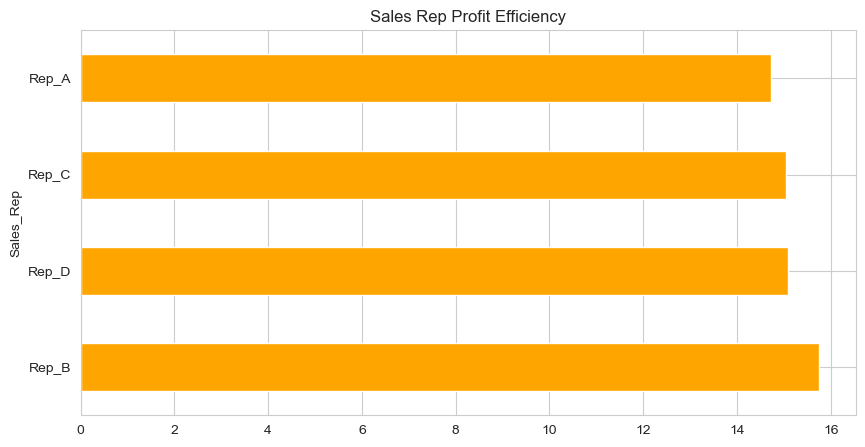

In [28]:
# Group by Sales Rep and calculate average Profit Margin
rep_margin = df_balanced.groupby('Sales_Rep')['Profit_Margin'].mean().sort_values(ascending=False)

print("Sales Reps sorted by Profit Margin Efficiency:")
print(rep_margin)

# Visualize it
rep_margin.plot(kind='barh', color='orange', title='Sales Rep Profit Efficiency')

Sales Reps Efficiency (Avg Profit Margin):
Sales_Rep
Rep_B    15.745074
Rep_D    15.094911
Rep_C    15.037073
Rep_A    14.732489
Name: Profit_Margin, dtype: float64


<Axes: title={'center': 'Top Sales Reps by Profit Margin'}, xlabel='Sales_Rep'>

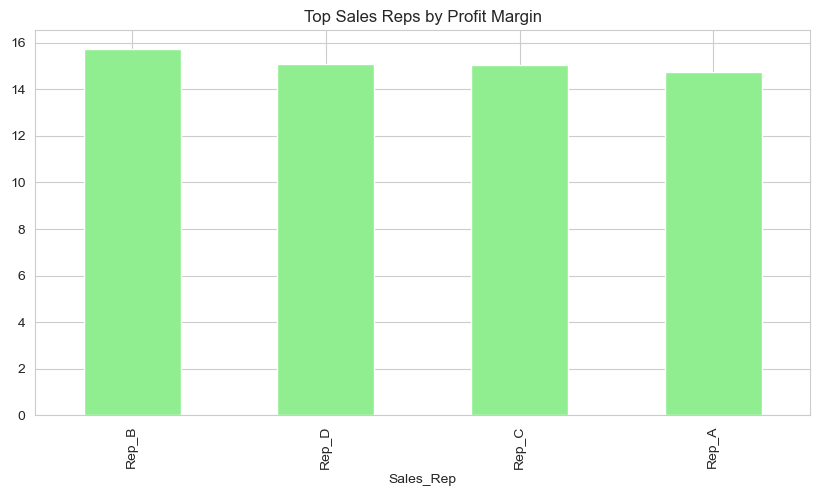

In [29]:
# Group by Sales_Rep and calculate average Profit_Margin
rep_efficiency = df_balanced.groupby('Sales_Rep')['Profit_Margin'].mean().sort_values(ascending=False)

# Display the numbers
print("Sales Reps Efficiency (Avg Profit Margin):")
print(rep_efficiency)

# Create the chart
rep_efficiency.plot(kind='bar', color='lightgreen', title='Top Sales Reps by Profit Margin')

In [30]:
# Group by Sales_Rep and calculate average Profit_Margin
rep_margin = df_balanced.groupby('Sales_Rep')['Profit_Margin'].mean().sort_values(ascending=False)

print("Sales Reps by Average Profit Margin:")
print(rep_margin)

Sales Reps by Average Profit Margin:
Sales_Rep
Rep_B    15.745074
Rep_D    15.094911
Rep_C    15.037073
Rep_A    14.732489
Name: Profit_Margin, dtype: float64


In [31]:
# Compare average discount per payment method
discount_diff = df_balanced.groupby('Payment_Method')['Discount'].mean().sort_values(ascending=False)

print("Average Discount per Payment Method:")
print(discount_diff)

Average Discount per Payment Method:
Payment_Method
Online      2535.894009
POS         2494.533333
Cash        2494.345794
Transfer    2476.448430
Name: Discount, dtype: float64


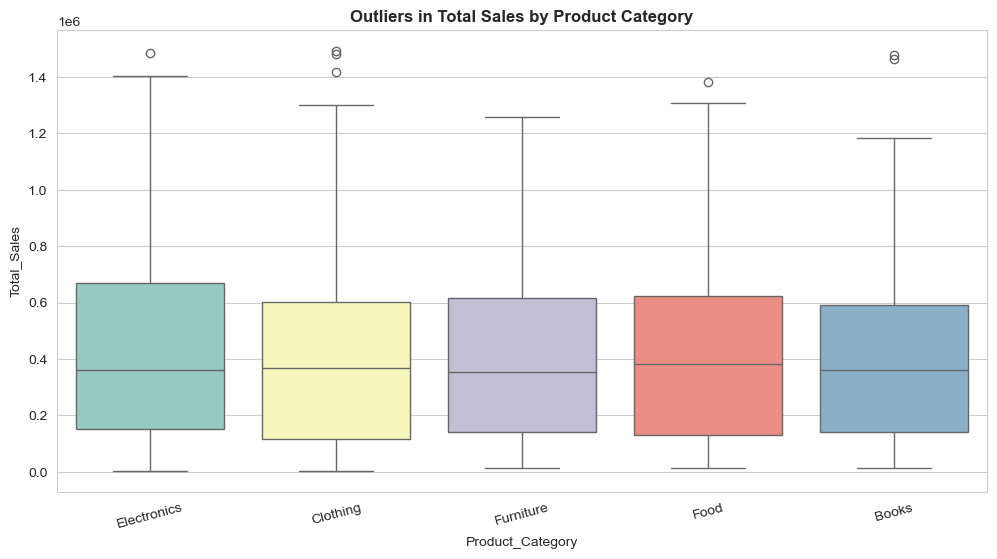

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_balanced, x='Product_Category', y='Total_Sales', palette='Set3')
plt.title('Outliers in Total Sales by Product Category', fontweight='bold')
plt.xticks(rotation=15)
plt.show()

# Conclusion: Look for the category with the most individual dots 
# appearing above the top whisker in the chart.

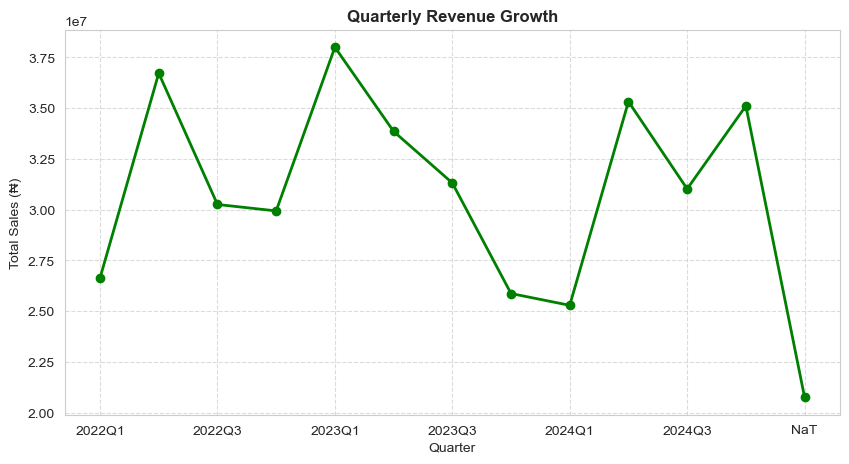

In [35]:
# Group by Quarter and sum the Total_Sales
quarterly_growth = df_balanced.groupby('Quarter')['Total_Sales'].sum()

# Plot the growth
plt.figure(figsize=(10, 5))
quarterly_growth.plot(kind='line', marker='o', color='green', linewidth=2)
plt.title('Quarterly Revenue Growth', fontweight='bold')
plt.ylabel('Total Sales (₦)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()